# Plot tracer concentrations for the sensitivity analysis

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

import xarray as xr
import numpy as np

import warnings

import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
out_dir = "./plots/"

## Choose Runs

In [3]:
path = "/work/bb1174/user/jason/hra_data/hra_post_proc"

path1 = path + "/pp_hra_25/"
path2 = path + "/pp_hra_27/"
path3 = path + "/pp_hra_31/"
path4 = path + "/pp_hra_23/"
path5 = path + "/pp_hra_28/"
path6 = path + "/pp_hra_29/"

names = ["E0", "E10", "E30", "E50", "E70", "E70*"]

colors = [
    "#719ecd",
    "#65c15b",
    "#f7ba0b",
    "#ff9c4b",
    "#ee665c",
    "#ac8bca",
]

## Read Data

In [4]:
cb_start_time = np.datetime64("2025-05-30T00:00:00")
cb_end_time = np.datetime64("2025-05-30T04:00:00")

cb_slice = slice(cb_start_time, cb_end_time)
t = cb_slice

In [5]:
def read_data(path):
    files = path + "*.nc"
    dset = xr.open_mfdataset(
        files,
        engine="netcdf4",
        combine="by_coords",
    )
    print("Dataset loaded")
    return dset


d1 = read_data(path1)
d2 = read_data(path2)
d3 = read_data(path3)
d4 = read_data(path4)
d5 = read_data(path5)
d6 = read_data(path6)

dsets = [d1, d2, d3, d4, d5, d6]

Dataset loaded
Dataset loaded
Dataset loaded
Dataset loaded
Dataset loaded
Dataset loaded


In [6]:
lon = d5.lon
lat = d5.lat
lon_fire = -113.8
lat_fire = 56.9

dz = -d5.height.diff("height")

### Panel 1: Calculate tracer transport across 10km

In [7]:
tropoheight = 10000
unit_conversion = 1e-9

In [8]:
def calculate_total_mass_injection(dset, cb_slice, tropoheight):

    volc = dset.ca_volc.sel(
        height=tropoheight,
        method="nearest",
    ).squeeze()

    w = dset.vert_speed.sel(
        height=tropoheight,
        method="nearest",
    ).squeeze()

    area = dset.cell_area

    t_flux = volc * w * area
    t_flux = t_flux.where(t_flux > 0, 0)

    mass_transport = (
        t_flux
        .sum("ncells")
        .sel(time=cb_slice)
    )

    # Convert mass flux [kg s^-1] to mass per 30-min timestep [kg]
    total_mass_inj = (
        mass_transport * 30 * 60
    ).sum("time")

    return total_mass_inj


transports_10 = []

for dset in dsets:

    transport_10 = (
        calculate_total_mass_injection(
            dset,
            cb_slice,
            tropoheight,
        )
        * unit_conversion
    )

    transports_10.append(transport_10.values)

### Panel 2: Condensed water path around fires

In [9]:
radius = 1
# Fire position
lon_fire = [-113.8]
lat_fire = [56.9]


In [10]:
lon_grid = lon.isel(time=1).values
lat_grid = lat.isel(time=1).values

dlon = lon_grid[:, None] - lon_fire
dlat = lat_grid[:, None] - lat_fire

distance = np.sqrt(dlon**2 + dlat**2)
fire_region_mask = (distance <= radius).any(axis=1)

In [11]:
fire_water_paths = []

for dset in dsets:

    water_path = (
        (dset["qvol"] * dz)
        .sum("height")
        .where(fire_region_mask)
        .sel(time=cb_slice)
        .mean()
    )

    fire_water_paths.append(water_path.values)

### Panel 3: Injection height

In [12]:
fire_time = np.datetime64('2025-05-30T04:00:00.000000000')

In [13]:
def quantile_height(dset, dz, t, quantile=0.99):

    ds = (
        dset.ca_volc
        .mean("ncells")
        .sel(time=t)
    )

    qplume_sum = (ds * dz)[::-1].cumsum()
    qplume_100 = qplume_sum.max(dim="height")
    qplume_q = qplume_100 * quantile

    height_q = ds.height.where(qplume_sum > qplume_q)
    height_q_min = height_q.min(dim="height")

    return height_q_min.values

In [14]:
inj_heights = []

for dset in dsets:
    inj_height = quantile_height(
        dset,
        dz,
        fire_time,
    ) / 1000

    inj_heights.append(inj_height)

### Panel 4: Maximum Vertical Velocities

In [15]:
def get_vert_speed(d, t):
    return (
        d.vert_speed
        .sel(time=t)
        .compute()
        .quantile(
            0.999,
            dim=["ncells", "height", "time"],
        )
    )

In [16]:
wspeeds = []

for dset in dsets:
    wspeeds.append(
        get_vert_speed(dset, cb_slice)
    )

### Panel 5: Updraft Area

In [17]:
w_threshold = 1  # m s^-1

In [18]:
def count_updraft_cells(dset, t, threshold=1):

    da = dset.vert_speed.sel(time=t).max("height")

    mask = da >= threshold

    number = (
        mask.sum(dim=["ncells", "time"]).compute().values
        / len(da.time.values)
        / len(dset.ncells.values)
    )

    return number * 100

In [19]:
wareas = []

for dset in dsets:
    wareas.append(
        count_updraft_cells(dset, cb_slice, w_threshold)
    )

### Panel 6: Aerosol Reservoir


In [20]:
kg2g = 1000

In [21]:
def compute_reservoir(dset, top_height, mytime):

    reservoir = (
            dset.ca_volc
            .sel(height=slice(top_height, 0))
            * dz.sel(height=slice(top_height, 0))
            ).sel(time=mytime).sum("height").mean("ncells")
    

    return reservoir

In [22]:
my_time = np.datetime64("2025-05-30T00:00:00")

reses_start = []

for dset in dsets:

    res = compute_reservoir(
        dset,
        1500,
        my_time,
    ) * kg2g

    reses_start.append(res.compute())
    

In [23]:
my_time = np.datetime64("2025-05-30T04:00:00")

reses_end = []

for dset in dsets:

    res = compute_reservoir(
        dset,
        1500,
        my_time,
    ) * kg2g

    reses_end.append(res.compute())
    

## Put everything together

In [24]:
# =================================================
# GENERAL SETTINGS
# =================================================

fs = 14

# Experiment labels and colors
bar_labels = names

# Panel labels
panel_labels = ["a", "b", "c", "d", "e", "f"]

# Figure size
figsize = (16, 8)

# Default number of decimals for value labels
default_decimals = 2


# =================================================
# PANEL SETTINGS
# =================================================

panel_info = [

    {
        "title": "Injection height",
        "data": np.array(inj_heights),
        "ylabel": "km",
        "ylim": (10, 12),
        "decimals": 1,
    },

    {
        "title": "Transport across 10km",
        "data": np.array(transports_10),
        "ylabel": "Tg",
        "ylim": (0, 0.03),
        "decimals": 3,
    },

    {
        "title": "Boundary Layer Burden",
        "data": np.array(reses_start),
        "data2": np.array(reses_end),
        "label1": "00:00 UTC",
        "label2": "04:00 UTC",
        "ylabel": r"g m$^{-2}$",
        "ylim": (0, 0.15),
        "decimals": 2,
    },

    {
        "title": "99.9th Percentile of Vertical Windspeeds",
        "data": np.array(wspeeds),
        "ylabel": r"m s$^{-1}$",
        "ylim": (2, 2.6),
        "decimals": 2,
    },

    {
        "title": r"Area with w > 1m$\,$s$^{-1}$",
        "data": np.array(wareas),
        "ylabel": "%",
        "ylim": (3, 5),
        "decimals": 1,
    },

    {
        "title": "Cond. water path around fire",
        "data": np.array(fire_water_paths),
        "ylabel": r"kg m$^{-2}$",
        "decimals": 2,
    },
]


# =================================================
# PLOT APPEARANCE
# =================================================

# Bar width for double-bar panels
bar_width = 0.38

# Transparency of second bar in double-bar panels
second_bar_alpha = 0.45

# Broken-axis marker
break_offset = 0.03
break_fontsize = fs + 4

# Value-label positions
value_label_y1 = 0.03
value_label_y2 = 0.10
value_label_fs = fs - 3

# Axis spine width
spine_width = 0.7

# X-axis label rotation
x_label_rotation = 45

# Legend
legend_fs = fs - 2

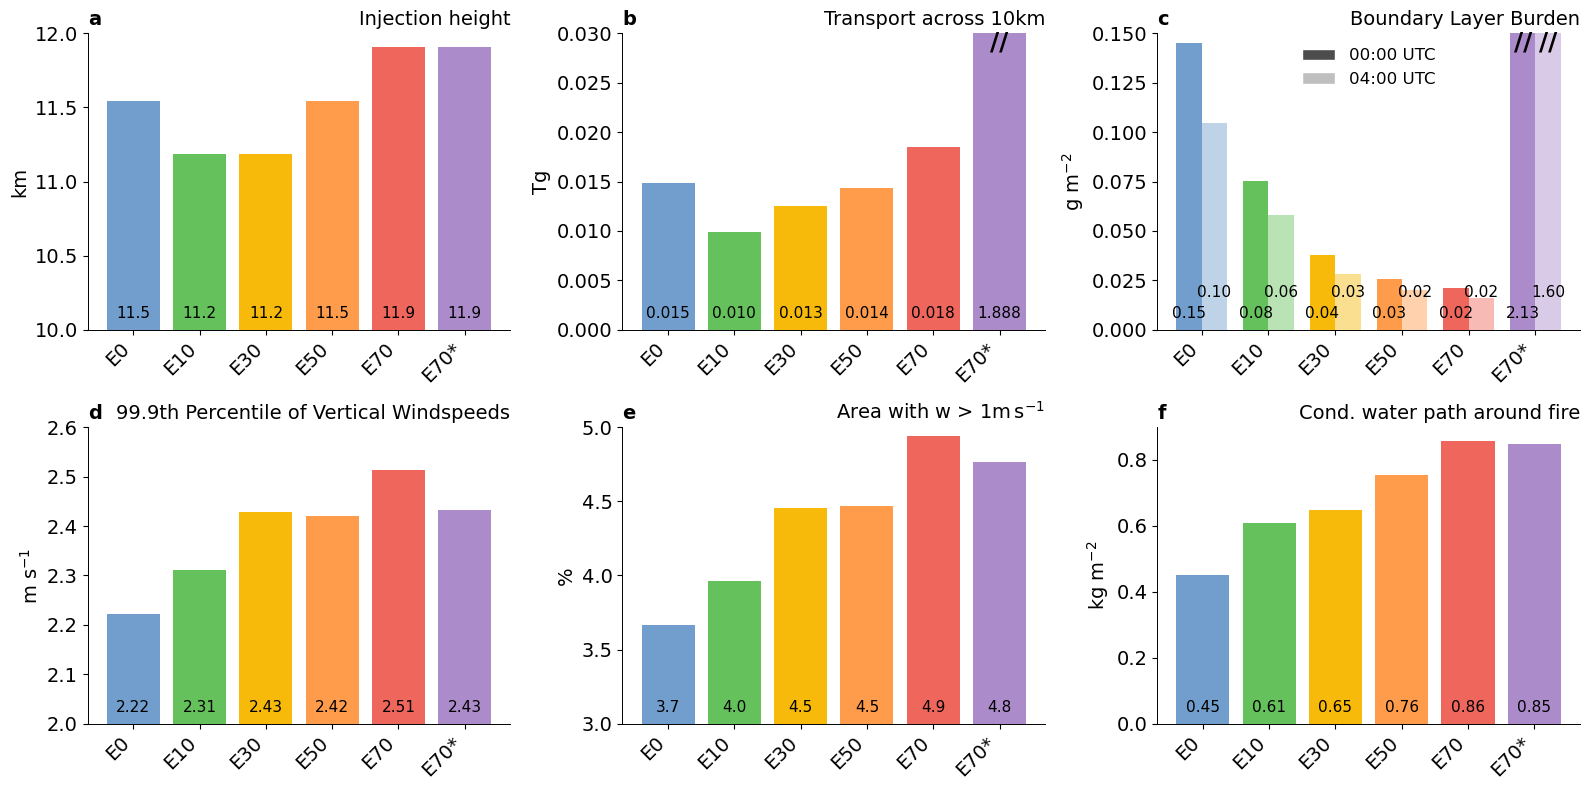

In [25]:
# =================================================
# CREATE FIGURE
# =================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=figsize,
)

axes = axes.flatten()


# =================================================
# LOOP OVER PANELS
# =================================================

for ax, info, panel_label in zip(
    axes,
    panel_info,
    panel_labels,
):

    data = np.asarray(info["data"])
    decimals = info.get("decimals", default_decimals)

    x = np.arange(len(data))


    # -------------------------------------------------
    # Clip bars at ymax
    # -------------------------------------------------

    if "ylim" in info:

        ymin, ymax = info["ylim"]
        plot_data = np.minimum(data, ymax)

    else:

        plot_data = data


    # -------------------------------------------------
    # Single or double bar plot
    # -------------------------------------------------

    if "data2" in info:

        data2 = np.asarray(info["data2"])

        if "ylim" in info:
            plot_data2 = np.minimum(data2, ymax)
        else:
            plot_data2 = data2

        bars1 = ax.bar(
            x - bar_width / 2,
            plot_data,
            width=bar_width,
            color=colors,
        )

        bars2 = ax.bar(
            x + bar_width / 2,
            plot_data2,
            width=bar_width,
            color=colors,
            alpha=second_bar_alpha,
        )

        bars = [bars1, bars2]

    else:

        bars1 = ax.bar(
            x,
            plot_data,
            color=colors,
        )

        bars = [bars1]


    # -------------------------------------------------
    # Broken-axis symbols
    # -------------------------------------------------

    if "ylim" in info:

        yrange = ymax - ymin

        for bar, actual_val in zip(bars[0], data):

            if actual_val > ymax:

                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    ymax - break_offset * yrange,
                    "//",
                    ha="center",
                    va="center",
                    fontsize=break_fontsize,
                    fontweight="bold",
                    clip_on=False,
                    zorder=10,
                )

        if "data2" in info:

            for bar, actual_val in zip(bars[1], data2):

                if actual_val > ymax:

                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        ymax - break_offset * yrange,
                        "//",
                        ha="center",
                        va="center",
                        fontsize=break_fontsize,
                        fontweight="bold",
                        clip_on=False,
                        zorder=10,
                    )


    # -------------------------------------------------
    # Axis formatting
    # -------------------------------------------------

    ax.set_xticks(x)

    ax.set_xticklabels(
        bar_labels,
        rotation=x_label_rotation,
        ha="right",
        fontsize=fs,
    )

    ax.set_title(
        panel_label,
        loc="left",
        fontsize=fs,
        fontweight="bold",
    )

    ax.set_title(
        info["title"],
        loc="right",
        fontsize=fs,
    )

    ax.set_ylabel(
        info["ylabel"],
        fontsize=fs,
    )

    if "ylim" in info:
        ax.set_ylim(info["ylim"])

    ax.tick_params(
        axis="both",
        labelsize=fs,
    )


    # -------------------------------------------------
    # Spines
    # -------------------------------------------------

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(spine_width)
    ax.spines["bottom"].set_linewidth(spine_width)


    # -------------------------------------------------
    # Value labels
    # -------------------------------------------------

    for bar, val in zip(bars[0], data):

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value_label_y1,
            f"{val:.{decimals}f}",
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="bottom",
            fontsize=value_label_fs,
            clip_on=False,
        )


    if "data2" in info:

        for bar, val in zip(bars[1], data2):

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value_label_y2,
                f"{val:.{decimals}f}",
                transform=ax.get_xaxis_transform(),
                ha="center",
                va="bottom",
                fontsize=value_label_fs,
                clip_on=False,
            )


        # -------------------------------------------------
        # Legend
        # -------------------------------------------------

        legend_handles = [

            Patch(
                facecolor="0.3",
                edgecolor="White",
                label=info.get("label1", "00:00 UTC"),
            ),

            Patch(
                facecolor="0.75",
                edgecolor="White",
                label=info.get("label2", "04:00 UTC"),
            ),

        ]

        ax.legend(
            handles=legend_handles,
            frameon=False,
            fontsize=legend_fs,
        )


# =================================================
# LAYOUT
# =================================================

plt.tight_layout()

plt.show()
fig.savefig(out_dir + "bar_plot.png", dpi=300, bbox_inches="tight")

### Calculate the maximum surface sensible heat flux for Table 1 

In [26]:
divider = [-1, -10, -30, -50, -70, -70] # To make sure everything looks as expected
converter = -1000 # in kW & positive from surface to atmosphere

for i,d in enumerate(dsets):
    print("Maximum heat flux " + names[i] +":     "+ str(d.sel(time = cb_slice).hfss.where(fire_region_mask).compute().quantile(0.01).values/ converter)) 
    print("Sanity Check      "+ names[i] +":     "+ str(d.sel(time = cb_slice).hfss.where(fire_region_mask).compute().quantile(0.01).values/divider[i]))
    

Maximum heat flux E0:     0.29678369140625
Sanity Check      E0:     296.78369140625
Maximum heat flux E10:     1.537726806640625
Sanity Check      E10:     153.7726806640625
Maximum heat flux E30:     4.695862607421874
Sanity Check      E30:     156.52875358072913
Maximum heat flux E50:     7.874313715820312
Sanity Check      E50:     157.48627431640625
Maximum heat flux E70:     11.008736328125
Sanity Check      E70:     157.26766183035716
Maximum heat flux E70*:     10.839360624999998
Sanity Check      E70*:     154.8480089285714


In [27]:
my_time ='2025-05-30T00:00:00'


In [29]:
divider = [-1, -10, -30, -50, -70, -70] # To make sure everything looks as expected
converter = 273.15 # in °C

for i,d in enumerate(dsets):
    print("Maximum Surface Temperature " + names[i] +":     "+ str(d.sel(time = my_time).ta.isel(height = -1).where(fire_region_mask).compute().quantile(1).values - converter)) 

    

Maximum Surface Temperature E0:     27.192529296875023
Maximum Surface Temperature E10:     53.88338623046877
Maximum Surface Temperature E30:     89.38613281250002
Maximum Surface Temperature E50:     139.5132995605469
Maximum Surface Temperature E70:     138.19912109375002
Maximum Surface Temperature E70*:     156.91594848632815
